In [7]:
from langgraph.graph import StateGraph, END
from langgraph.types import interrupt, Command
from langgraph.checkpoint.memory import MemorySaver
from langchain_openai import ChatOpenAI
from typing import TypedDict, Optional, List
from dotenv import load_dotenv
import os
import json
import uuid

load_dotenv()

model = ChatOpenAI(api_key=os.getenv("OPENAI_API_KEY"), model="gpt-4o-mini")

In [8]:
class ChatState(TypedDict):
    user_input: str
    intent: Optional[str]          # enquiry|search|bookings|fallback
    parsed_slots: Optional[dict]   # {city, bedrooms, check_in, check_out, max_price, amenities}
    search_results: Optional[list] # ranked properties
    relaxation_level: int          # 0=strict, 1=drop amenities, 2=expand area
    response: Optional[dict]
    error: Optional[str]
    booking_action: Optional[str]  # cancel|modify|check — detected sub-intent
    human_approval: Optional[str]  # yes|no — result of HITL interrupt

In [9]:
def classify_intent(state: ChatState) -> ChatState:
    prompt = f"""Classify the user's message into exactly one of these intents:
- search: user wants to find/search for a property to rent or buy
- enquiry: user has a question about a specific property or general property info
- bookings: user wants to book, cancel, or check their booking
- fallback: anything else

User message: "{state['user_input']}"

Respond with ONLY one word: search, enquiry, bookings, or fallback."""

    intent = model.invoke(prompt).content.strip().lower()
    if intent not in ["search", "enquiry", "bookings"]:
        intent = "fallback"
    return {**state, "intent": intent}


def parse_enquiry(state: ChatState) -> ChatState:
    prompt = f"""Extract property search details from this message and return JSON only.

User message: "{state['user_input']}"

Return a JSON object with these keys (use null for missing values):
{{
  "city": string or null,
  "bedrooms": number or null,
  "check_in": string or null,
  "check_out": string or null,
  "max_price": number or null,
  "amenities": list of strings or []
}}

Return ONLY the JSON, no explanation."""

    try:
        raw = model.invoke(prompt).content.strip()
        raw = raw.replace("```json", "").replace("```", "").strip()
        slots = json.loads(raw)
    except Exception:
        slots = {"city": None, "bedrooms": None, "check_in": None,
                 "check_out": None, "max_price": None, "amenities": []}

    return {**state, "parsed_slots": slots, "relaxation_level": 0}


def search_properties(state: ChatState) -> ChatState:
    slots = state.get("parsed_slots") or {}
    level = state.get("relaxation_level", 0)

    criteria = dict(slots)
    if level >= 1:
        criteria["amenities"] = []
    if level >= 2:
        if criteria.get("bedrooms"):
            criteria["bedrooms"] = None
        if criteria.get("max_price"):
            criteria["max_price"] = (criteria["max_price"] or 0) * 1.2

    mock_results = []
    if criteria.get("city"):
        mock_results = [
            {"id": "P001", "name": f"Cozy Flat in {criteria['city']}",
             "bedrooms": criteria.get("bedrooms") or 2, "price": 150,
             "amenities": ["wifi", "parking"]},
            {"id": "P002", "name": f"Modern Studio in {criteria['city']}",
             "bedrooms": 1, "price": 90, "amenities": ["wifi"]},
            {"id": "P003", "name": f"Luxury Apartment in {criteria['city']}",
             "bedrooms": criteria.get("bedrooms") or 3, "price": 280,
             "amenities": ["wifi", "pool", "gym", "parking"]},
        ]

    return {**state, "search_results": mock_results}


def check_and_relax(state: ChatState) -> ChatState:
    level = state.get("relaxation_level", 0) + 1
    return {**state, "relaxation_level": level}


def handle_enquiry(state: ChatState) -> ChatState:
    prompt = f"""You are a helpful property enquiry assistant for a rental platform.
Answer the user's property question helpfully and concisely.

User question: "{state['user_input']}\""""

    answer = model.invoke(prompt).content.strip()
    return {**state, "response": {"type": "enquiry", "message": answer}}


# ── HITL: booking sub-intent detection ──────────────────────────────────────

def detect_booking_action(state: ChatState) -> ChatState:
    prompt = f"""Classify this booking message into exactly one of:
- cancel: user wants to cancel a booking
- modify: user wants to change or modify a booking
- check: user wants to check booking status or details

User message: "{state['user_input']}"

Respond with ONLY one word: cancel, modify, or check."""

    action = model.invoke(prompt).content.strip().lower()
    if action not in ["cancel", "modify", "check"]:
        action = "check"
    return {**state, "booking_action": action}


def confirm_cancel(state: ChatState) -> ChatState:
    """Interrupt — pause graph and wait for human confirmation."""
    human_reply = interrupt({
        "prompt": "Are you sure you want to cancel your booking? Reply 'yes' to confirm or 'no' to keep it.",
        "booking_action": state.get("booking_action"),
        "user_input": state["user_input"],
    })
    approval = str(human_reply).strip().lower()
    if approval not in ["yes", "no"]:
        approval = "no"
    return {**state, "human_approval": approval}


def execute_cancel(state: ChatState) -> ChatState:
    # Replace with actual cancel API call
    return {**state, "response": {
        "type": "booking",
        "message": "Your booking has been successfully cancelled. A confirmation email will be sent shortly."
    }}


def abort_cancel(state: ChatState) -> ChatState:
    return {**state, "response": {
        "type": "booking",
        "message": "Cancellation aborted. Your booking remains active."
    }}


def handle_booking(state: ChatState) -> ChatState:
    prompt = f"""You are a helpful booking assistant for a property rental platform.
Help the user with their booking request. If you need more info, ask for it.

User message: "{state['user_input']}\""""

    answer = model.invoke(prompt).content.strip()
    return {**state, "response": {"type": "booking", "message": answer}}


# ── HITL: enquiry confirmation ───────────────────────────────────────────────

def confirm_enquiry(state: ChatState) -> ChatState:
    """Interrupt — pause graph and wait for human to confirm sending enquiry."""
    human_reply = interrupt({
        "prompt": "Ready to send your enquiry to the property owner. Reply 'yes' to send or 'no' to cancel.",
        "enquiry_preview": state.get("response", {}).get("message", ""),
    })
    approval = str(human_reply).strip().lower()
    if approval not in ["yes", "no"]:
        approval = "no"
    return {**state, "human_approval": approval}


def submit_enquiry(state: ChatState) -> ChatState:
    # Replace with actual enquiry submission API
    return {**state, "response": {
        "type": "enquiry",
        "message": f"Enquiry sent to the property owner. They will respond within 24 hours.\n\nYour question: {state['user_input']}"
    }}


def handle_fallback(state: ChatState) -> ChatState:
    return {**state, "response": {
        "type": "fallback",
        "message": "I can help you search for properties, answer property questions, or assist with bookings. What would you like to do?"
    }}


def format_response(state: ChatState) -> ChatState:
    results = state.get("search_results")

    if results is not None:
        if not results:
            message = "No properties found matching your criteria. Try broadening your search."
        else:
            lines = [f"Found {len(results)} propert{'y' if len(results)==1 else 'ies'}:"]
            for p in results:
                lines.append(f"  • {p['name']} — {p['bedrooms']} bed, £{p['price']}/night")
            if state.get("relaxation_level", 0) > 0:
                lines.append("(Results relaxed to find matches — original filters were too strict)")
            message = "\n".join(lines)
        return {**state, "response": {"type": "search", "message": message}}

    return state


# ── routing helpers ──────────────────────────────────────────────────────────

def route_booking_action(state: ChatState):
    return state.get("booking_action", "check")


def route_human_approval(state: ChatState):
    return state.get("human_approval", "no")

In [10]:
def route_intent(state: ChatState):
    intent = state["intent"]
    if intent == "search":
        return "enquiry_parser"
    elif intent == "enquiry":
        return "enquiry_agent"
    elif intent == "bookings":
        return "booking_agent"
    return "fallback"


graph = StateGraph(ChatState)

# ── nodes ────────────────────────────────────────────────────────────────────
graph.add_node("intent_classifier",  classify_intent)
graph.add_node("enquiry_parser",     parse_enquiry)
graph.add_node("property_search",    search_properties)
graph.add_node("relaxation_check",   check_and_relax)
graph.add_node("enquiry_agent",      handle_enquiry)
graph.add_node("confirm_enquiry",    confirm_enquiry)   # HITL
graph.add_node("submit_enquiry",     submit_enquiry)
graph.add_node("booking_agent",      detect_booking_action)
graph.add_node("confirm_cancel",     confirm_cancel)    # HITL
graph.add_node("execute_cancel",     execute_cancel)
graph.add_node("abort_cancel",       abort_cancel)
graph.add_node("booking_handler",    handle_booking)
graph.add_node("fallback",           handle_fallback)
graph.add_node("response_formatter", format_response)

# ── entry ─────────────────────────────────────────────────────────────────────
graph.set_entry_point("intent_classifier")

# ── intent routing ────────────────────────────────────────────────────────────
graph.add_conditional_edges(
    "intent_classifier", route_intent,
    {
        "enquiry_parser": "enquiry_parser",
        "enquiry_agent":  "enquiry_agent",
        "booking_agent":  "booking_agent",
        "fallback":       "fallback",
    }
)

# ── search flow ───────────────────────────────────────────────────────────────
graph.add_edge("enquiry_parser", "property_search")
graph.add_conditional_edges(
    "property_search",
    lambda s: "relax" if len(s.get("search_results") or []) < 3
              and s.get("relaxation_level", 0) < 2 else "format",
    {"relax": "relaxation_check", "format": "response_formatter"}
)
graph.add_edge("relaxation_check", "property_search")

# ── enquiry flow with HITL ────────────────────────────────────────────────────
# enquiry_agent generates answer → confirm_enquiry INTERRUPTS for approval
# yes → submit_enquiry (send to owner) → formatter
# no  → formatter (just show the answer, don't send)
graph.add_edge("enquiry_agent", "confirm_enquiry")
graph.add_conditional_edges(
    "confirm_enquiry", route_human_approval,
    {
        "yes": "submit_enquiry",
        "no":  "response_formatter",
    }
)
graph.add_edge("submit_enquiry", "response_formatter")

# ── booking flow with HITL ────────────────────────────────────────────────────
# booking_agent detects sub-intent (cancel / modify / check)
# cancel → confirm_cancel INTERRUPTS for approval
#   yes → execute_cancel → formatter
#   no  → abort_cancel   → formatter
# modify/check → booking_handler (LLM) → formatter
graph.add_conditional_edges(
    "booking_agent", route_booking_action,
    {
        "cancel": "confirm_cancel",
        "modify": "booking_handler",
        "check":  "booking_handler",
    }
)
graph.add_conditional_edges(
    "confirm_cancel", route_human_approval,
    {
        "yes": "execute_cancel",
        "no":  "abort_cancel",
    }
)
graph.add_edge("execute_cancel",  "response_formatter")
graph.add_edge("abort_cancel",    "response_formatter")
graph.add_edge("booking_handler", "response_formatter")

# ── fallback ──────────────────────────────────────────────────────────────────
graph.add_edge("fallback",            "response_formatter")
graph.add_edge("response_formatter",  END)

# ── compile with checkpointer (required for interrupt/resume) ─────────────────
checkpointer = MemorySaver()
app = graph.compile(checkpointer=checkpointer)
print("Graph compiled successfully")

Graph compiled successfully


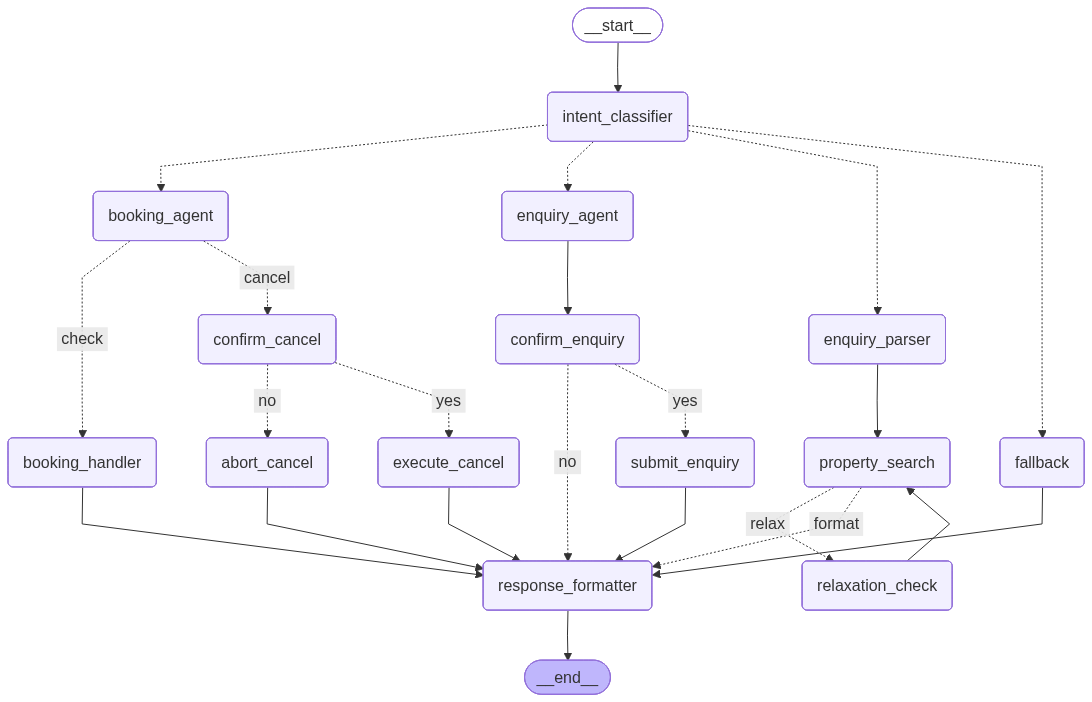

In [11]:
app

In [12]:
def chat(user_input: str, thread_id: str = None) -> str:
    """
    Send a message. Returns thread_id so caller can resume interrupted flows.
    If graph pauses at HITL interrupt, prompts user and resumes automatically.
    """
    if thread_id is None:
        thread_id = str(uuid.uuid4())

    config = {"configurable": {"thread_id": thread_id}}

    initial_state = {
        "user_input": user_input,
        "intent": None,
        "parsed_slots": None,
        "search_results": None,
        "relaxation_level": 0,
        "response": None,
        "error": None,
        "booking_action": None,
        "human_approval": None,
    }

    app.invoke(initial_state, config)

    # Check if graph paused at an interrupt
    snapshot = app.get_state(config)
    if snapshot.next:
        # Extract interrupt payload from the pending task
        payload = {}
        for task in snapshot.tasks:
            if task.interrupts:
                payload = task.interrupts[0].value
                break

        print(f"\n[HITL] {payload.get('prompt', 'Confirm?')}")
        if payload.get("enquiry_preview"):
            print(f"  Preview: {payload['enquiry_preview'][:120]}...")
        human_input = input("  Your response (yes/no): ").strip().lower()

        # Resume graph with human answer
        result = app.invoke(Command(resume=human_input), config)
    else:
        result = app.get_state(config).values

    print(f"Intent:  {result.get('intent')}")
    if result.get("booking_action"):
        print(f"Action:  {result['booking_action']}")
    if result.get("parsed_slots"):
        print(f"Slots:   {result['parsed_slots']}")
    if result.get("response"):
        print(f"Response: {result['response']['message']}")
    print()
    return thread_id


# ── tests ─────────────────────────────────────────────────────────────────────
print("=== Search (no HITL) ===")
chat("I'm looking for a 2 bedroom flat in London for next weekend")

print("=== Enquiry (HITL: confirm before sending to owner) ===")
chat("What documents do I need to rent a property?")

print("=== Cancel booking (HITL: confirm cancel) ===")
chat("I want to cancel my booking")

print("=== Check booking (no HITL) ===")
chat("What is the status of my booking?")

=== Search (no HITL) ===
Intent:  search
Slots:   {'city': 'London', 'bedrooms': 2, 'check_in': '2023-10-20', 'check_out': '2023-10-22', 'max_price': None, 'amenities': []}
Response: Found 3 properties:
  • Cozy Flat in London — 2 bed, £150/night
  • Modern Studio in London — 1 bed, £90/night
  • Luxury Apartment in London — 2 bed, £280/night

=== Enquiry (HITL: confirm before sending to owner) ===

[HITL] Ready to send your enquiry to the property owner. Reply 'yes' to send or 'no' to cancel.
  Preview: To rent a property, you typically need the following documents:

1. **Proof of Identity**: A government-issued ID like a...
Intent:  enquiry
Response: Enquiry sent to the property owner. They will respond within 24 hours.

Your question: What documents do I need to rent a property?

=== Cancel booking (HITL: confirm cancel) ===

[HITL] Are you sure you want to cancel your booking? Reply 'yes' to confirm or 'no' to keep it.
Intent:  bookings
Action:  cancel
Response: Your booking has be

'72359731-0832-42e1-ad03-0795f972fb7c'